# Primal Dual Hybrid Graient

In [376]:
import odl
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse.linalg import spsolve, lsqr
from scipy.sparse import lil_matrix, diags
from scipy.special import gamma
from mpl_toolkits.mplot3d import Axes3D

In [377]:
#  ------Building the space"""
R = 1.0
h = 0.05
r = 0.2
# given: R, r, h
start = -R - r

xx = np.arange(start, R + r, h)
yy = np.arange(start, R + r, h)

Nx, Ny = len(xx), len(yy)

# ODL space with the same sampling step h
space = odl.uniform_discr(
    min_pt=[xx[0], yy[0]],
    max_pt=[xx[-1] + h, yy[-1] + h],   # important: +h to match arange-excluded endpoint
    shape=[Nx, Ny],
    dtype='float64'
)

x = space.grid.coord_vectors[0]
y = space.grid.coord_vectors[1]

X, Y = np.meshgrid(x, y, indexing='ij')

In [378]:
# Calculate coordinates neighbouring within the mean value radius
I_max = int(np.ceil(r/h))
Q = (r/h)**2
cord = []
for i in range(-I_max, I_max+1):
    for j in range(-I_max, I_max+1):
        if i**2 + j**2 < Q:  # L2 radius
        #if np.abs(i) + np.abs(j) < Q:  # L1 radius
            cord.append((i, j))
cord = np.array(cord)

# --- Square domain ---
Z = np.zeros_like(X, dtype=bool)
Z[(np.abs(Y) <= 1.0) & (np.abs(X) <= 1.0)] = True

In [379]:
v =Z*(1 - np.max(np.array([np.abs(X), np.abs(Y)]), axis=0))
u = np.zeros_like(v)
p=3
tau_reg = 0.2

In [380]:
#   ---Test Cell
v = space.element(v)
u = space.element(u)
# --- convert ODL elements to numpy arrays (shape: (Nx, Ny)) ---
V = v.asarray()
U = u.asarray()

print("U shape:", U.shape, " ||U||:", np.linalg.norm(U))
print("V shape:", V.shape, " ||V||:", np.linalg.norm(V))

U shape: (48, 48)  ||U||: 0.0
V shape: (48, 48)  ||V||: 16.3401346384


In [381]:
class DataFunctional(odl.solvers.Functional):
    """
    f(u) = 1/p * ||u - v||_p^p
    prox_f(u) = (u + v) / 2
    """
    def __init__(self, space, v, p):
        self.v = v
        self.p = float(p)
        super().__init__(space=space, linear=False)

    def _call(self, u):
        U = u.asarray()
        V = self.v.asarray()
        return (1.0 / self.p) * float(np.sum(np.abs(U - V) ** self.p))

    @property
    def proximal(self):
        v = self.v
        space = self.domain

        def make_proximal(tau_pdhg):
            class ProxF(odl.Operator):
                def __init__(self):
                    super().__init__(domain=space, range=space, linear=False)

                def _call(self, u, out=None):
                    result = space.element((u.asarray() + v.asarray()) / 2.0)
                    if out is None:
                        return result
                    out.assign(result)
                    return out

            return ProxF()
        return make_proximal

In [382]:
class RegFunctional(odl.solvers.Functional):
    """
    g(zeta) = tau/p * ||zeta||_p^p
    g*(zeta) = tau^{1-q}/q * ||zeta||_q^q
    prox_{g*}(zeta) = zeta / (1 + 1/tau)
    """
    def __init__(self, space, p, tau_reg):
        self.p   = float(p)
        self.tau = float(tau_reg)
        self.q   = self.p / (self.p - 1.0)   # 1/p + 1/q = 1
        super().__init__(space=space, linear=False)

    def _call(self, zeta):
        norm_grad = np.linalg.norm(zeta, axis=0)
        total = self.tau * (1.0 / self.p) * np.linalg.norm(norm_grad.flatten(), ord=self.p) ** self.p
        return total

    @property
    def convex_conj(self):
        tau_reg = self.tau
        q = self.q
        space = self.domain

        class ConjG(odl.solvers.Functional):
            def __init__(self):
                super().__init__(space=space, linear=False)

            def _call(self, zeta):
                norm_grad = np.linalg.norm(zeta, axis=0)
                total = np.linalg.norm(norm_grad.flatten(), ord=self.q) ** self.q
                return (tau_reg ** (1.0 - q) / q) * total

            @property
            def proximal(self):
                def make_proximal(sigma):
                    scale = 1.0 / (1.0 + 1.0 / tau_reg)

                    class ProxConjG(odl.Operator):
                        def __init__(self):
                            super().__init__(
                                domain=space, range=space, linear=False)
                        def _call(self, zeta, out=None):
                            result = space.element(scale * zeta)
                            if out is None:
                                return result
                            out.assign(result)
                            return out

                    return ProxConjG()
                return make_proximal

        return ConjG()

In [383]:
# Gradient operator
gradient = L = odl.Gradient(space, method='central', pad_mode='symmetric')

# Matrix of operators
op = odl.BroadcastOperator(odl.IdentityOperator(space), gradient)

# Estimated operator norm, add 10 percent to ensure ||K||_2^2 * sigma * tau < 1
op_norm = 1.1 * odl.power_method_opnorm(op)

niter = 200  # Number of iterations
tau_pdhg = 1.0 / op_norm  # Step size for the primal variable
sigma = 1.0 / op_norm  # Step size for the dual variable

In [384]:
f = DataFunctional(space, v, p)          # f.proximal(tau)(u)
g = RegFunctional(L.range, p, tau_reg)       # g.convex_conj.proximal(sigma)(zeta)


x = space.element(u.copy())

values  = [float(f(x)) + float(g(L(x)))]   # ← was undefined before cb
x_norms = [float(x.norm())]                 # ← was undefined before cb
print(f"Initial fval: {values[0]:.6f}   ||x||: {x_norms[0]:.6f}")

def cb(x):
    fval  = float(f(x)) + float(g(L(x)))
    xnorm = float(x.norm())
    values.append(fval)
    x_norms.append(xnorm)
    print(f"fval: {fval:.6f}   ||x||: {xnorm:.6f}")


odl.solvers.pdhg(
    x,                  # starting point, updated in-place → solution here after
    f=f,                # needs f.proximal
    g=g,                # needs g.convex_conj.proximal
    L=L,                # linear operator: grad(u)
    niter=200,          # number of iterations
    tau=tau_pdhg,           # let ODL compute from L automatically
    sigma=sigma,         # let ODL compute from L automatically
    callback=cb
)


print("------- Summary -------")
print(f"First fval: {values[0]:.6f}")
print(f"Last  fval: {values[-1]:.6f}")
print(f"Iterations: {len(values) - 1}")

Initial fval: 53.444250   ||x||: 0.000000
fval: 18.861130   ||x||: 0.408503
fval: 41.344974   ||x||: 0.612356
fval: 64.066058   ||x||: 0.714219
fval: 78.491360   ||x||: 0.765141
fval: 86.495452   ||x||: 0.790600
fval: 90.698611   ||x||: 0.803329
fval: 92.850885   ||x||: 0.809694
fval: 93.939750   ||x||: 0.812876
fval: 94.487371   ||x||: 0.814467
fval: 94.761979   ||x||: 0.815263
fval: 94.899483   ||x||: 0.815661
fval: 94.968285   ||x||: 0.815860
fval: 95.002698   ||x||: 0.815959
fval: 95.019908   ||x||: 0.816009
fval: 95.028514   ||x||: 0.816034
fval: 95.032817   ||x||: 0.816046
fval: 95.034968   ||x||: 0.816052
fval: 95.036044   ||x||: 0.816055
fval: 95.036582   ||x||: 0.816057
fval: 95.036851   ||x||: 0.816058
fval: 95.036985   ||x||: 0.816058
fval: 95.037053   ||x||: 0.816058
fval: 95.037086   ||x||: 0.816058
fval: 95.037103   ||x||: 0.816058
fval: 95.037111   ||x||: 0.816058
fval: 95.037116   ||x||: 0.816058
fval: 95.037118   ||x||: 0.816058
fval: 95.037119   ||x||: 0.816058
fval: 

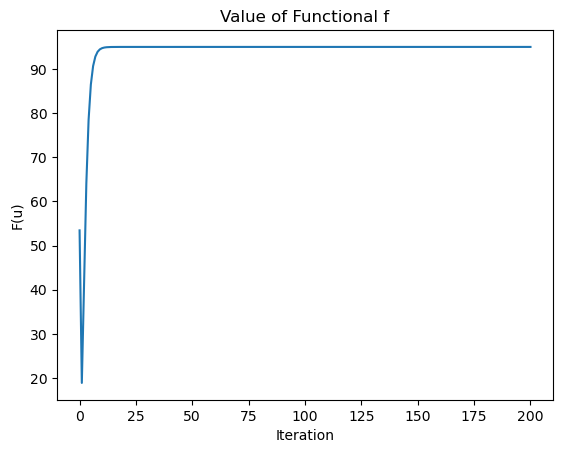

In [385]:
plt.plot(values)
plt.xlabel("Iteration")
plt.ylabel("F(u)")
plt.title("Value of Functional f")
plt.show()

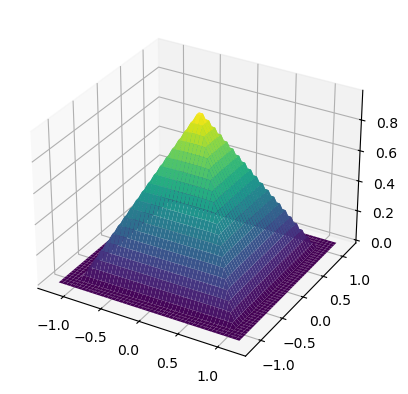

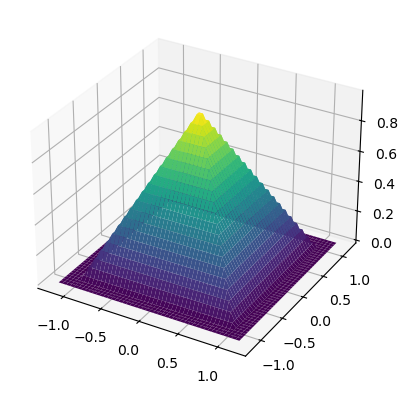

In [386]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,x, cmap='viridis')
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,V, cmap='viridis')
plt.show()

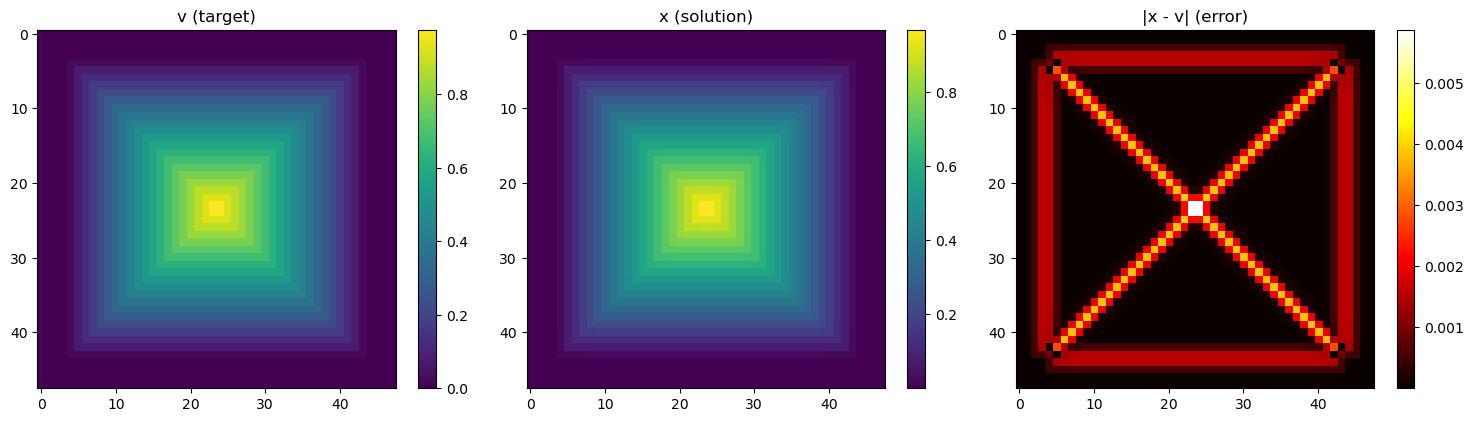

In [387]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(v.asarray(),               cmap='viridis')
axes[0].set_title("v (target)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(x.asarray(),               cmap='viridis')
axes[1].set_title("x (solution)")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.abs(x.asarray() - v.asarray()), cmap='hot')
axes[2].set_title("|x - v| (error)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()